# 교내 근로 공고 채널·공개성 분석

**목적**: 크롤링·정제된 역대 교내 근로 공고를 근거 수치로 바꾼다 —
(1) 각 부서가 어떤 채널(청년광장/서담/학과·기관 홈페이지)로 공고를 내왔고 언제 끊겼는지,
(2) 공고 안에 정보가 얼마나 기재됐는가(**정보 충실도**),
(3) 채용이 공개 경로로 이뤄지는가(**채용 공개성**) — 조직도 대비 공고를 아예 안 올리는 부서는 비공개(지인 추천) 채용 신호다.

**재현 파이프라인** (모든 로직은 레포 코드에 있음):

```bash
python -m crawler crawl all --pages 0     # 수집 → data/raw/
python -m crawler refine --all --campus-only   # Gemini 정제 → data/refined/
python -m crawler enrich                  # Gemini 보강: 조직명→조직도 매핑, 직무 추출
python -m analysis                        # 분석 CSV 재생성 → data/analysis/
```

이 노트북은 [`ai/analysis`](../analysis) 패키지를 import해 **시각화와 해설만** 담당한다.

| 소스 | 채널 | 설명 |
|---|---|---|
| `scc` | 청년광장 | 공식 교내조교모집 게시판 (로그인 불필요) |
| `ssodam` | 서담 | 학생 커뮤니티 모집공고 게시판 (**로그인 필요**, 비공식) |
| `dept_*` | 학과·기관 홈페이지 | 46개 학과·기관 게시판 (표준 CMS + 이공계·곤자가 등 자체 게시판) |

## 1. 데이터 로드

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from analysis import (CH_ORDER, add_transparency, channel_matrix,
                      cross_posting_role_window, cross_posting_stats, dedup_recruitments,
                      last_posting, lead_times, load_postings, posting_gaps)
from analysis.metrics import FIELD_LABELS, add_dormancy_flags, dept_tier_comparison
from analysis.orgs import load_org_map

# 한글 폰트 — 운영체제별로 사용 가능한 첫 번째 폰트를 선택
import platform
from matplotlib import font_manager

_KOREAN_FONTS = {
    'Darwin': ['AppleGothic'],
    'Windows': ['Malgun Gothic'],
    'Linux': ['NanumGothic', 'Noto Sans CJK KR'],   # 없으면: apt install fonts-nanum
}
_available = {f.name for f in font_manager.fontManager.ttflist}
for _name in _KOREAN_FONTS.get(platform.system(), []) + [
        'AppleGothic', 'Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR']:
    if _name in _available:
        matplotlib.rcParams['font.family'] = _name
        break
else:
    print('경고: 한글 폰트를 찾지 못했습니다 — 차트 한글이 깨질 수 있습니다')
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 60)

# 채널 색 (Tableau 10 팔레트) — 모든 차트에서 동일하게 유지한다
CH_COLORS = {'청년광장': '#4E79A7', '서담': '#F28E2B', '학과·기관 홈페이지': '#76B7B2'}
CH_CLIST = [CH_COLORS[c] for c in CH_ORDER]
GOOD, BAD, ACCENT = '#59A14F', '#E15759', '#4E79A7'   # 랭킹 상/하위, 강조
BAR_KW = dict(edgecolor='white', linewidth=0.6)

df = add_transparency(load_postings())
print(f"교내 근로 공고 {len(df):,}건 / 부서 식별 {df['org'].notna().sum():,}건 / "
      f"직무 추출 {df['role'].notna().sum():,}건")
print()
print(df.groupby('channel').size().rename('공고 수').to_frame()
        .assign(비중=lambda t: (t['공고 수'] / len(df)).map('{:.1%}'.format)))

교내 근로 공고 2,595건 / 부서 식별 2,554건 / 직무 추출 2,578건

            공고 수     비중
channel                
서담           812  31.3%
청년광장        1127  43.4%
학과·기관 홈페이지   656  25.3%


## 2. 조직명 정규화

`organization` 표기 변형(예: `곤자가 국제학사 사감실`/`곤자가국제학사`, `입학팀`/`입학처`)은
**Gemini가 공식 조직도와 대조해 만든 매핑**(`data/refined/org_map.json`,
`python -m crawler enrich --orgs` 산출)으로 통합한다. 매핑에 없는 표기는
규칙 기반 정규화(`analysis/orgs.py`)로 폴백한다.

In [2]:
org_map = load_org_map()
mapped = sum(1 for v in org_map.values() if v)
print(f"Gemini 조직명 매핑: 고유 표기 {len(org_map)}개 중 조직도 단위 매핑 {mapped}개, "
      f"조직도 외 조직 {len(org_map) - mapped}개")
print(f"정규화 후 조직 수: {df['org'].nunique()}개 (원본 표기 {df['organization'].nunique()}개)")
print(f"organization 결측 {df['org'].isna().sum()}건은 부서별 분석에서 제외")

Gemini 조직명 매핑: 고유 표기 357개 중 조직도 단위 매핑 269개, 조직도 외 조직 88개
정규화 후 조직 수: 160개 (원본 표기 357개)
organization 결측 41건은 부서별 분석에서 제외


## 3. 개요 — 연도별 채널 규모

수집된 전 기간을 반영한다 (2014년 이전은 표본이 적어 추이 해석에 주의).

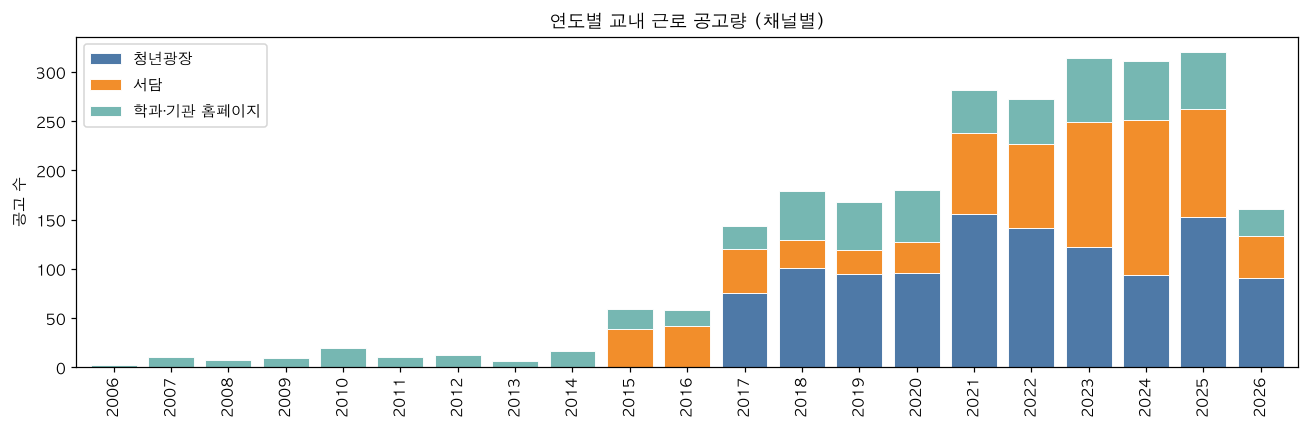

In [3]:
yr = (df[df['year'].notna()]
      .pivot_table(index='year', columns='channel', values='post_id', aggfunc='count')
      .fillna(0))[CH_ORDER]
yr.index = yr.index.astype(int)

fig, ax = plt.subplots(figsize=(12, 4))
yr.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=CH_CLIST, **BAR_KW)
ax.set_title('연도별 교내 근로 공고량 (채널별)')
ax.set_xlabel(''); ax.set_ylabel('공고 수')
ax.legend(title='')
plt.tight_layout(); plt.show()

## 4. 시기별 변화 — 채널 지형은 고정된 것이 아니다

청년광장         2015–19 평균 33% → 2024–26 평균 45% (+12%p)
서담           2015–19 평균 40% → 2024–26 평균 37% (-3%p)
학과·기관 홈페이지   2015–19 평균 27% → 2024–26 평균 18% (-9%p)


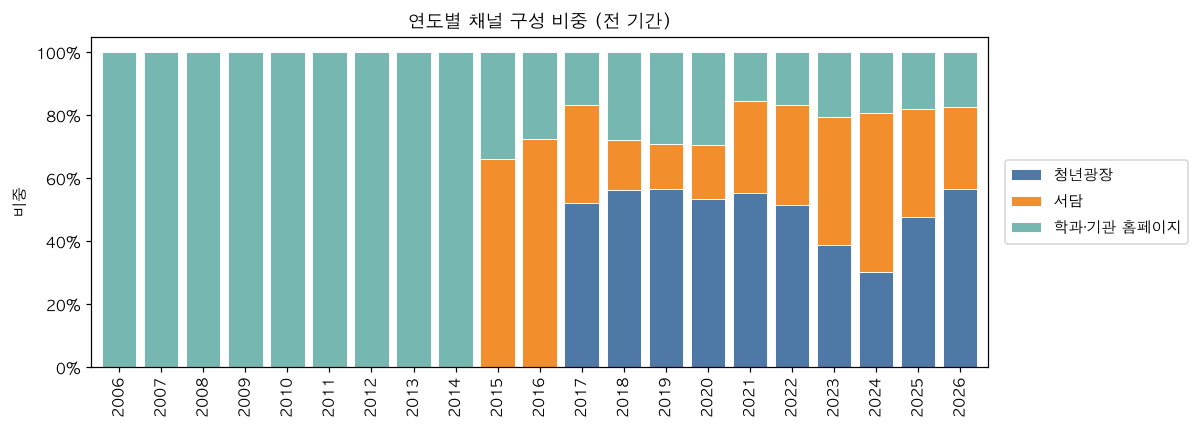

In [4]:
yr_pct = yr.div(yr.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 4))
yr_pct.plot(kind='bar', stacked=True, ax=ax, width=0.82, color=CH_CLIST, **BAR_KW)
ax.set_title('연도별 채널 구성 비중 (전 기간)')
ax.set_xlabel(''); ax.set_ylabel('비중')
ax.yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(); plt.show()

for c in CH_ORDER:
    a, b = yr_pct.loc[2015:2019, c].mean(), yr_pct.loc[2024:2026, c].mean()
    print(f'{c:12s} 2015–19 평균 {a:.0%} → 2024–26 평균 {b:.0%} ({(b - a) * 100:+.0f}%p)')

공고가 가장 몰리는 달: 8월(472건), 2월(436건), 12월(313건)
상위 3개월에 전체 공고의 48%가 집중


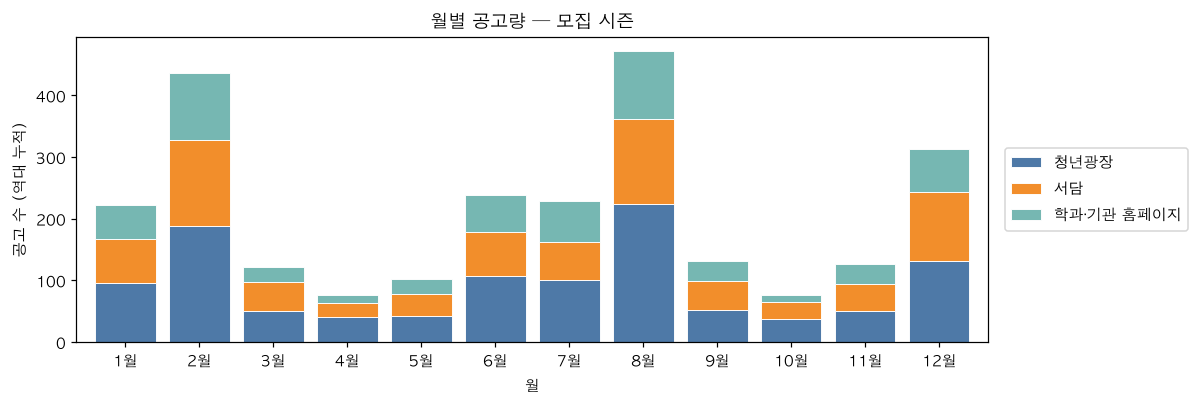

In [5]:
# 월별 시즌성 — 언제 공고가 몰리는가
sea = df[df['posted_date'].notna()].copy()
sea['month'] = sea['posted_date'].dt.month
monthly = (sea.pivot_table(index='month', columns='channel', values='post_id', aggfunc='count')
           .reindex(range(1, 13)).fillna(0))[CH_ORDER]

fig, ax = plt.subplots(figsize=(11, 3.8))
monthly.plot(kind='bar', stacked=True, ax=ax, width=0.82, color=CH_CLIST, **BAR_KW)
ax.set_title('월별 공고량 — 모집 시즌')
ax.set_xlabel('월'); ax.set_ylabel('공고 수 (역대 누적)')
ax.set_xticklabels([f'{m}월' for m in range(1, 13)], rotation=0)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(); plt.show()

top_months = monthly.sum(axis=1).nlargest(3)
print('공고가 가장 몰리는 달:', ', '.join(f'{m}월({int(v)}건)' for m, v in top_months.items()))
print(f'상위 3개월에 전체 공고의 {top_months.sum() / monthly.sum().sum():.0%}가 집중')

## 5. 부서별 공고 채널 사용 현황

In [6]:
mat = channel_matrix(df)
print(f"부서 수: {len(mat)}개")

combo = mat[CH_ORDER].gt(0)
n1 = (mat['사용채널수'] == 1).sum()
print(f"단일 채널만 사용하는 부서 {n1}개 ({n1 / len(mat):.0%}), "
      f"부서당 평균 사용 채널 {mat['사용채널수'].mean():.2f}개")

ssodam_only = mat[(mat['서담'] > 0) & (mat['청년광장'] == 0) & (mat['학과·기관 홈페이지'] == 0)]
print(f"서담(로그인 필요·비공식)에만 공고를 낸 부서 {len(ssodam_only)}개 "
      f"({len(ssodam_only) / len(mat):.0%}), 해당 공고 {ssodam_only['합계'].sum()}건")
mat.head(20)

부서 수: 160개
단일 채널만 사용하는 부서 68개 (42%), 부서당 평균 사용 채널 1.78개
서담(로그인 필요·비공식)에만 공고를 낸 부서 26개 (16%), 해당 공고 53건


channel,청년광장,서담,학과·기관 홈페이지,합계,사용채널수,주채널
org,,,,,,
곤자가 국제학사,47,35,109,191,3,학과·기관 홈페이지
전인교육원,104,32,48,184,3,청년광장
교수학습센터,70,14,3,87,3,청년광장
벨라르미노 학사,5,9,65,79,3,학과·기관 홈페이지
전문대학원행정팀,33,42,0,75,2,서담
법학전문대학원,55,4,3,62,3,청년광장
교양영어,30,31,0,61,2,서담
입학처,18,39,3,60,3,서담
중국문화,13,11,35,59,3,학과·기관 홈페이지


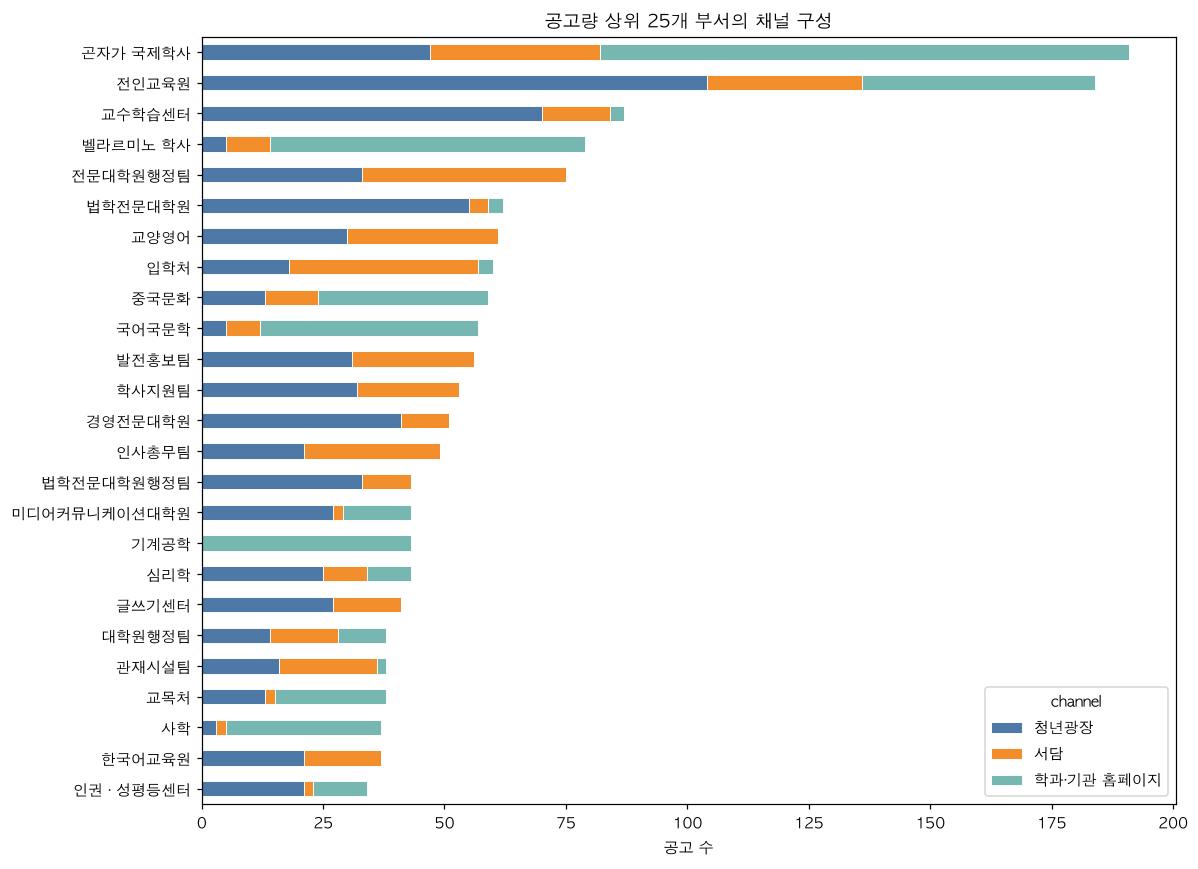

In [7]:
fig, ax = plt.subplots(figsize=(11, 8))
mat.head(25)[CH_ORDER].plot(kind='barh', stacked=True, ax=ax, color=CH_CLIST, **BAR_KW)
ax.invert_yaxis()
ax.set_title('공고량 상위 25개 부서의 채널 구성')
ax.set_xlabel('공고 수'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

## 6. 고유 공고(모집 건) 기준 재계산

위 공고량 통계는 게시물 단위라 **복수 채널 게시·재게시가 중복 집계**된다.
같은 부서·같은 직무의 공고가 7일 이내 간격이면 하나의 '모집 건'으로 병합해
(`analysis.dedup_recruitments`) 같은 통계를 다시 계산한다.
모집 건의 채널은 **첫 게시 채널** 기준이며, 복수 채널에 게시된 모집 건 비중은 별도 표기한다.

공고 2,595건 → 고유 모집 건 2,087건 (중복 병합 20%)
복수 채널에 게시된 모집 건: 15.2%


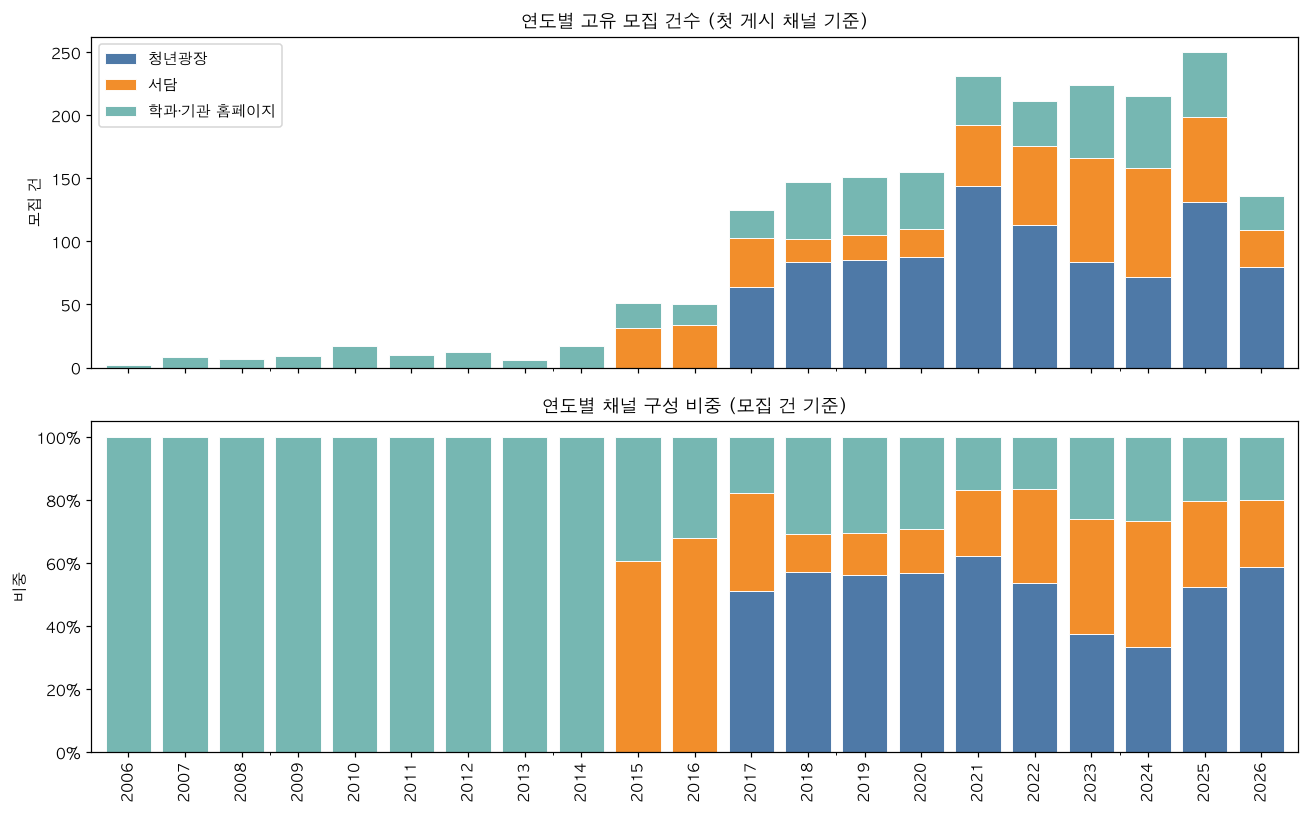

In [8]:
df_u = dedup_recruitments(df, window_days=7)
print(f"공고 {len(df):,}건 → 고유 모집 건 {len(df_u):,}건 (중복 병합 {1 - len(df_u) / len(df):.0%})")
print(f"복수 채널에 게시된 모집 건: {(df_u['채널수'] >= 2).mean():.1%}")

yr_u = (df_u[df_u['year'].notna()]
        .pivot_table(index='year', columns='channel', values='post_id', aggfunc='count')
        .fillna(0))[CH_ORDER]
yr_u.index = yr_u.index.astype(int)

fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)
yr_u.plot(kind='bar', stacked=True, ax=axes[0], width=0.8, color=CH_CLIST, **BAR_KW)
axes[0].set_title('연도별 고유 모집 건수 (첫 게시 채널 기준)')
axes[0].set_ylabel('모집 건'); axes[0].legend(title='')
yr_u_pct = yr_u.div(yr_u.sum(axis=1), axis=0)
yr_u_pct.plot(kind='bar', stacked=True, ax=axes[1], width=0.8, color=CH_CLIST, legend=False, **BAR_KW)
axes[1].set_title('연도별 채널 구성 비중 (모집 건 기준)')
axes[1].set_ylabel('비중'); axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
plt.tight_layout(); plt.show()

모집이 가장 몰리는 달: 8월(365건), 2월(339건), 12월(230건)
상위 3개월 집중도: 46%


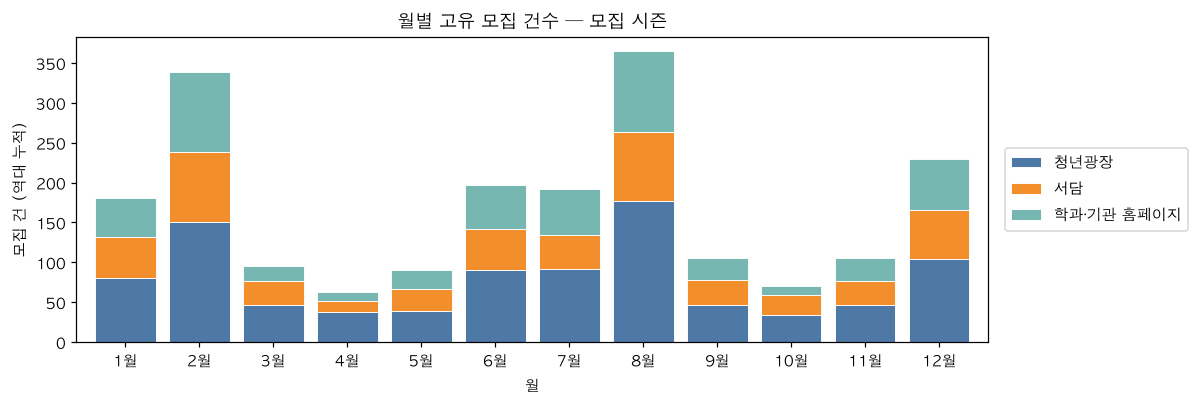

In [9]:
# 월별 시즌성 (모집 건 기준)
sea_u = df_u[df_u['posted_date'].notna()].copy()
sea_u['month'] = sea_u['posted_date'].dt.month
monthly_u = (sea_u.pivot_table(index='month', columns='channel', values='post_id', aggfunc='count')
             .reindex(range(1, 13)).fillna(0))[CH_ORDER]

fig, ax = plt.subplots(figsize=(11, 3.8))
monthly_u.plot(kind='bar', stacked=True, ax=ax, width=0.82, color=CH_CLIST, **BAR_KW)
ax.set_title('월별 고유 모집 건수 — 모집 시즌')
ax.set_xlabel('월'); ax.set_ylabel('모집 건 (역대 누적)')
ax.set_xticklabels([f'{m}월' for m in range(1, 13)], rotation=0)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(); plt.show()

top_months_u = monthly_u.sum(axis=1).nlargest(3)
print('모집이 가장 몰리는 달:', ', '.join(f'{m}월({int(v)}건)' for m, v in top_months_u.items()))
print(f'상위 3개월 집중도: {top_months_u.sum() / monthly_u.sum().sum():.0%}')

부서 수 160개 / 단일 채널만 사용 70개 (44%) / 서담 전용 28개
(공고 기준 5절: 단일 채널 68개 (42%), 서담 전용 26개)


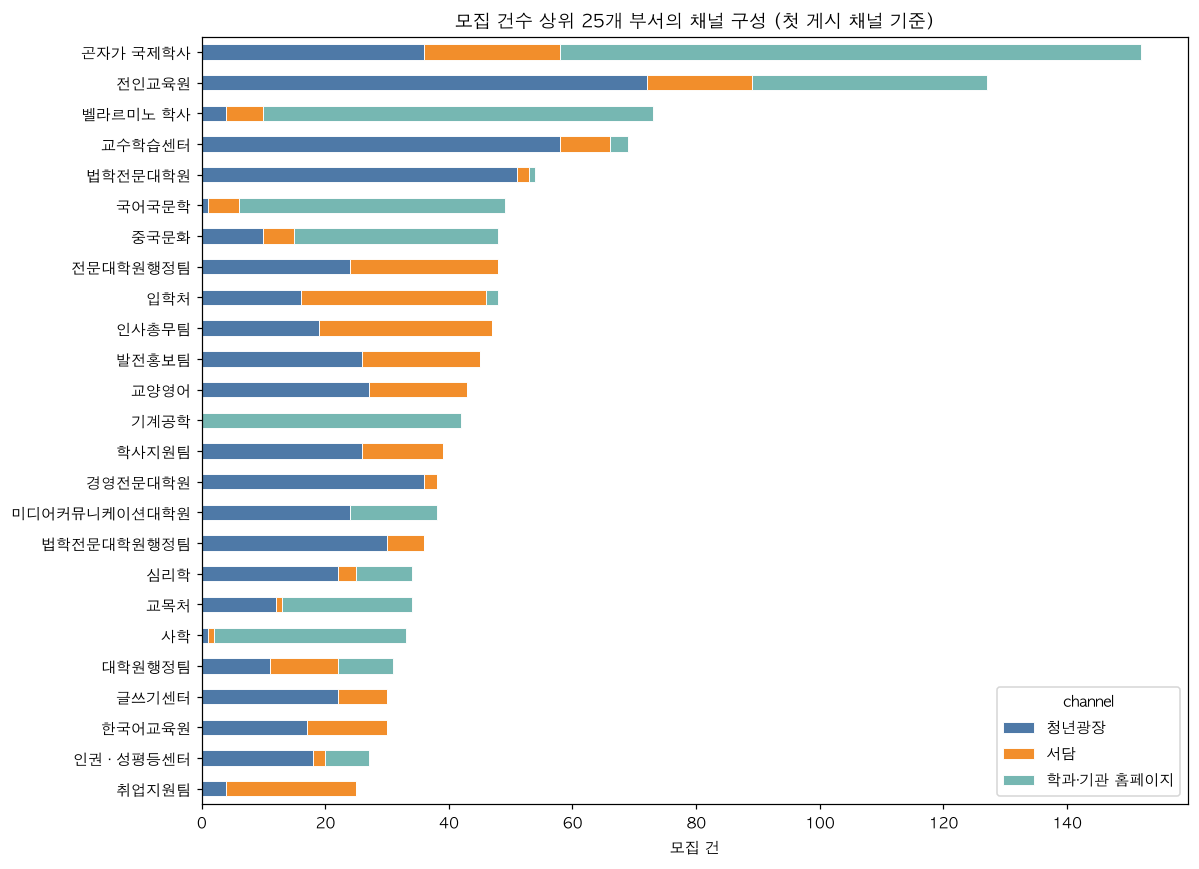

In [10]:
# 부서별 채널 사용 (모집 건 기준) — 공고 기준(5절)과 비교
mat_u = channel_matrix(df_u)
n1_u = (mat_u['사용채널수'] == 1).sum()
ssodam_only_u = mat_u[(mat_u['서담'] > 0) & (mat_u['청년광장'] == 0) & (mat_u['학과·기관 홈페이지'] == 0)]
print(f"부서 수 {len(mat_u)}개 / 단일 채널만 사용 {n1_u}개 ({n1_u / len(mat_u):.0%})"
      f" / 서담 전용 {len(ssodam_only_u)}개")
print(f"(공고 기준 5절: 단일 채널 {(mat['사용채널수'] == 1).sum()}개"
      f" ({(mat['사용채널수'] == 1).mean():.0%}), 서담 전용 {len(ssodam_only)}개)")

fig, ax = plt.subplots(figsize=(11, 8))
mat_u.head(25)[CH_ORDER].plot(kind='barh', stacked=True, ax=ax, color=CH_CLIST, **BAR_KW)
ax.invert_yaxis()
ax.set_title('모집 건수 상위 25개 부서의 채널 구성 (첫 게시 채널 기준)')
ax.set_xlabel('모집 건'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

## 7. 채용 공개성 — 공개 채널에 안 올리는 부서는 어디인가

**채용 공개성** = 채용이 누구나 접근 가능한 공개 경로로 이뤄지는가.
청년광장·서담 같은 공개 채널에 공고를 안 올리는 부서의 근로 자리는
지인 추천 등 **비공개 경로로 채워지고 있을 가능성**이 크다. 공식 조직도를 분모로
조직 단위별 게시 이력을 판정하고(`analysis.posting_gaps`), **학과 공개율**
(공개 채널 게시 학과 비중)을 공개성 지수로 쓴다.

| 등급 | 정의 |
|---|---|
| A. 공개 채널 게시 | 청년광장 또는 서담에 게시 이력 있음 |
| A-. 상위조직 단위로 게시 | 상위 조직(공고 5건 이상)이 대행 게시 |
| B. 자기 홈페이지에만 | 학과·기관 홈페이지에만 게시 이력 |
| C. 게시 이력 없음 | 수집 범위 내 어디에도 이력 없음 |

판정 기간 3개(**전체 / 2022년 이후 / 2025년 이후**)를 나란히 계산해
"예전엔 올렸지만 최근에 끊긴" 부서를 드러낸다. 청년광장·서담은 전수 수집이므로
공개 채널 부재 판정은 확정적이다.

In [11]:
gap = posting_gaps(df)
print(f"조직도 단위 {len(gap)}개 × 판정 기간 3개")
print("(기간별 판정은 게시일 기준 — 게시일 미상 공고는 '전체' 판정에만 반영)")
summary_gap = gap.groupby(['부문', '등급']).size().unstack(fill_value=0)
summary_gap['합계'] = summary_gap.sum(axis=1)
summary_gap

조직도 단위 169개 × 판정 기간 3개
(기간별 판정은 게시일 기준 — 게시일 미상 공고는 '전체' 판정에만 반영)


등급,A-. 상위조직 단위로 게시,A. 공개 채널 게시,B. 자기 홈페이지에만,C. 게시 이력 없음,합계
부문,,,,,
교육기관,4,7,0,0,11
대학,3,28,8,18,57
대학원,5,14,0,1,20
부속기관,0,10,1,7,18
총장 직속,0,0,0,2,2
행정부서,12,29,1,19,61


In [12]:
# 학부 학과·전공 집중 분석 — 모든 학과는 조교를 쓰므로 C등급은 강한 신호
tier_cmp = dept_tier_comparison(gap)

print(f"학부 학과·전공 {len(tier_cmp)}개 — 판정 기간별 분포")
for col in tier_cmp.columns:
    dist = tier_cmp[col].value_counts().sort_index()
    n_out = len(tier_cmp) - tier_cmp[col].str.startswith('A').sum()
    print(f"  {col:9s}: " + ', '.join(f'{k} {v}개' for k, v in dist.items())
          + f'  → 공개 채널 밖 {n_out}개 ({n_out / len(tier_cmp):.0%})')

worse = tier_cmp[tier_cmp['전체'].str.startswith('A') & ~tier_cmp['2025이후'].str.startswith('A')]
print(f"\n과거엔 공개 채널에 올렸지만 2025년 이후엔 끊긴 학과 ({len(worse)}개):")
print('  ' + (', '.join(worse.index) if len(worse) else '(없음)'))
tier_cmp

학부 학과·전공 32개 — 판정 기간별 분포
  전체       : A 공개채널 20개, A- 상위조직 2개, B 홈페이지만 6개, C 없음 4개  → 공개 채널 밖 10개 (31%)
  2022이후   : A 공개채널 15개, A- 상위조직 3개, B 홈페이지만 4개, C 없음 10개  → 공개 채널 밖 14개 (44%)
  2025이후   : A 공개채널 7개, A- 상위조직 3개, B 홈페이지만 4개, C 없음 18개  → 공개 채널 밖 22개 (69%)

과거엔 공개 채널에 올렸지만 2025년 이후엔 끊긴 학과 (12개):
  중국문화, 유럽문화, 정치외교학, 수학, 경제학, 신문방송학전공, 컴퓨터공학, 인공지능학, 경영학, 국제한국학, 아트&테크놀로지, 글로벌한국학


,전체,2022이후,2025이후
조직명,,,
국어국문학,A 공개채널,A 공개채널,A 공개채널
사학,A 공개채널,A 공개채널,A 공개채널
철학,A 공개채널,A 공개채널,A 공개채널
종교학,A 공개채널,A 공개채널,A 공개채널
영문학부,A 공개채널,A 공개채널,A 공개채널
사회학,A 공개채널,A 공개채널,A 공개채널
심리학,A 공개채널,A 공개채널,A 공개채널
글로벌한국학부,A 공개채널,A- 상위조직,A- 상위조직
게페르트국제학부,A- 상위조직,A- 상위조직,A- 상위조직


In [13]:
# 학과 외 부서 — C등급은 채용 수요 부재일 수 있어 '있다가 끊긴' 변화가 더 강한 신호
others = gap[gap['부문'] != '대학']
tbl = []
for sec, g in others.groupby('부문'):
    row = {'부문': sec, '단위수': len(g)}
    for col, label in [('등급', '전체'), ('등급_2022이후', '2022~'), ('등급_2025이후', '2025~')]:
        n = g[col].str.startswith('A').sum()
        row[f'공개게시 {label}'] = f'{n} ({n / len(g):.0%})'
    tbl.append(row)
display(pd.DataFrame(tbl).set_index('부문'))

worse_o = others[others['등급'].str.startswith('A') & ~others['등급_2025이후'].str.startswith('A')]
print(f"역대엔 공개 채널에 올렸지만 2025년 이후 게시가 없는 학과 외 부서 ({len(worse_o)}개):")
for sec, g in worse_o.groupby('부문'):
    print(f"  [{sec}] " + ', '.join(g['조직명'].tolist()))

역대엔 공개 채널에 올렸지만 2025년 이후 게시가 없는 학과 외 부서 (34개):
  [교육기관] AI·SW교육센터
  [대학원] 대학원혁신전략팀, 인재양성센터, 서강글로벌학술원, 전문대학원, 국제대학원, 가상융합전문대학원, 특수대학원, 공공정책대학원, 교육대학원, 경제대학원
  [부속기관] 도서관, 지식정보기획팀, 출판부
  [행정부서] 교목처, 교목팀, 예산팀, 재무팀, 디지털정보처, 정보전략팀, 정보개발팀, 대외교류처, 발전홍보팀, 연구진흥팀, 연구지원팀, 경영지원팀, 검수팀, 산학기획팀, 성과활용팀, 공동기기원, G-LAMP 사업단, 산학연협력센터, 판교캠퍼스사업단, 서강비즈니스센터


,단위수,공개게시 전체,공개게시 2022~,공개게시 2025~
부문,,,,
교육기관,11,11 (100%),10 (91%),10 (91%)
대학원,20,19 (95%),18 (90%),9 (45%)
부속기관,18,10 (56%),9 (50%),7 (39%)
총장 직속,2,0 (0%),0 (0%),0 (0%)
행정부서,61,41 (67%),26 (43%),21 (34%)


기준일(최신 게시일): 2026-07-16

[1건 이상] 대상 157개 중 휴면 73개 (46%)
[3건 이상] 대상 105개 중 휴면 34개 (32%)
[5건 이상] 대상 88개 중 휴면 22개 (25%)

5건 이상 휴면 (22개): 물리학, 영상대학원, 디지털정보처, 아트&테크놀로지, 트랜스내셔널인문학연구소, 게임&평생교육원, 경제학, 컴퓨터공학, 총동문회, 경제대학원, 공공정책대학원, 교육대학원, 사회과학대학행정팀, 생명과학, 고시반(토마스모어관), 메리홀, 발전홍보팀, 경제대학행정팀, 유럽문화, 수학, 재무팀, 인공지능학

3~4건 휴면 (12개): 교목팀, 신학연구소, 자연과학대학행정팀, 종교연구소, 서강교육그룹, 도서관, 경영대학, 지식융합미디어대학행정팀, 교양국어, 공과대학, 융합소프트웨어연계전공, 정치외교학

1~2건 휴면 (39개): 사회봉사센터, 커뮤니케이션학전공, 공학교육연구센터, 국제문화교육원, 지식융합대학행정팀, 교양영어 조교, 핀테크 연구센터, TNT 어학센터, 경영대 빅데이터 연구팀, STNT어학센터, 알바트로스어학센터, 서강매크로경영교육센터, 지식정보기획팀, 매크로경영교육센터, 국제대학원, 마포-서강 영어캠프 운영팀, 공과대학행정팀, 인공광합성연구센터, 마포-서강 영어캠프(MSEC) 운영본부, 바이오기술·투자전문인력양성센터, 국제한국학, 경영학, 학과사무실 및 산학협력단 현장실습센터, 마포중앙도서관 영어교육센터, 서강비즈니스센터, 일반대학원 제32대 총학생회, 예산팀, 대학원총학생회, 영원한 증언 프로젝트, 철학연구소, 신문방송학전공, 인문대학행정팀, 상담심리학전공, LINC 사업단 창업교육센터, LINC사업팀, 빅데이터사이언스연계전공, 현장실습지원센터, 가상자산연구소, 경제대학


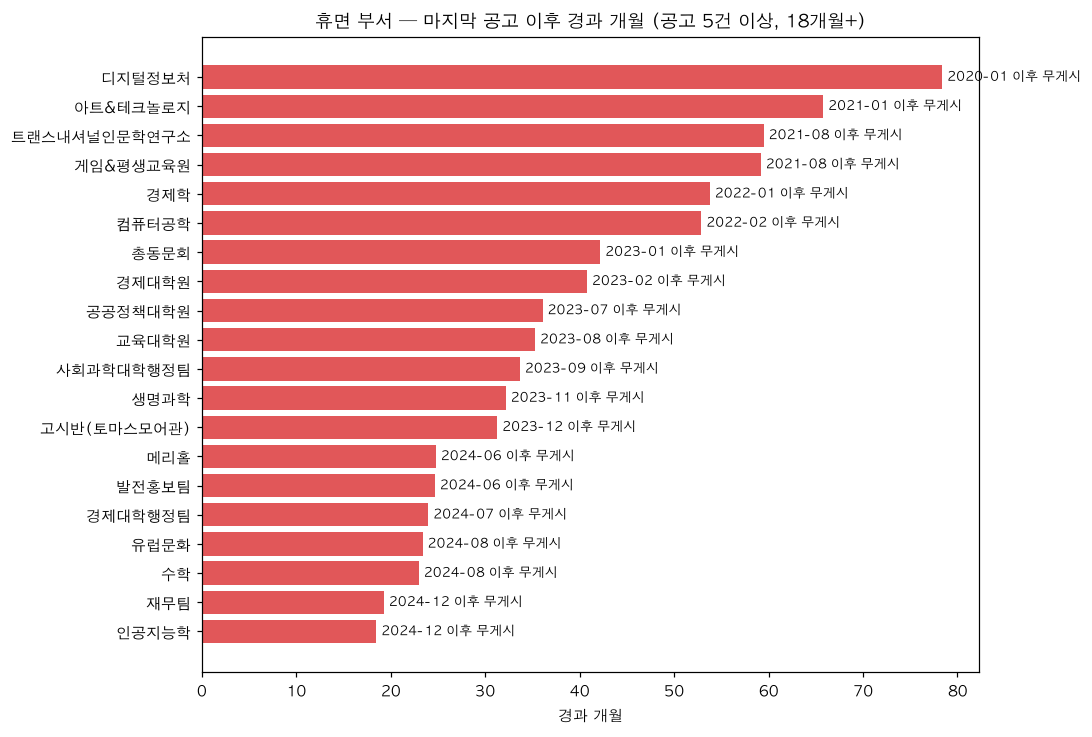

In [14]:
# 휴면 분석 — 언제부터 끊겼나. 기준(역대 공고 수)별로 셋 다 제시:
# 1건 이상 = 게시 이력이 있는 모든 부서 / 3건·5건 = 반복적으로 공개 모집하던 부서
last = add_dormancy_flags(last_posting(df))
asof = last.attrs['asof']
DORMANT_M = 18
print(f"기준일(최신 게시일): {asof:%Y-%m-%d}\n")
for n in (1, 3, 5):
    base = last[last['공고수'] >= n]
    dn = base[base[f'휴면_{n}건']]
    print(f"[{n}건 이상] 대상 {len(base)}개 중 휴면 {len(dn)}개 ({len(dn) / len(base):.0%})")
print()
dormant = last[last['휴면_5건']]
band35 = last[last['휴면_3건'] & ~last['휴면_5건']]
band13 = last[last['휴면_1건'] & ~last['휴면_3건']]
print(f"5건 이상 휴면 ({len(dormant)}개): " + ', '.join(dormant.sort_values('마지막공고').index))
print(f"\n3~4건 휴면 ({len(band35)}개): " + ', '.join(band35.sort_values('마지막공고').index))
print(f"\n1~2건 휴면 ({len(band13)}개): " + ', '.join(band13.sort_values('마지막공고').index))

plot_d = dormant.sort_values('마지막공고').tail(20)
fig, ax = plt.subplots(figsize=(10, max(4, 0.34 * len(plot_d))))
ax.barh(plot_d.index, plot_d['경과개월'], color=BAD)
for y, (v, dtm) in enumerate(zip(plot_d['경과개월'], plot_d['마지막공고'])):
    ax.text(v + 0.5, y, f"{dtm:%Y-%m} 이후 무게시", va='center', fontsize=8.5)
ax.set_title(f'휴면 부서 — 마지막 공고 이후 경과 개월 (공고 5건 이상, {DORMANT_M}개월+)')
ax.set_xlabel('경과 개월'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

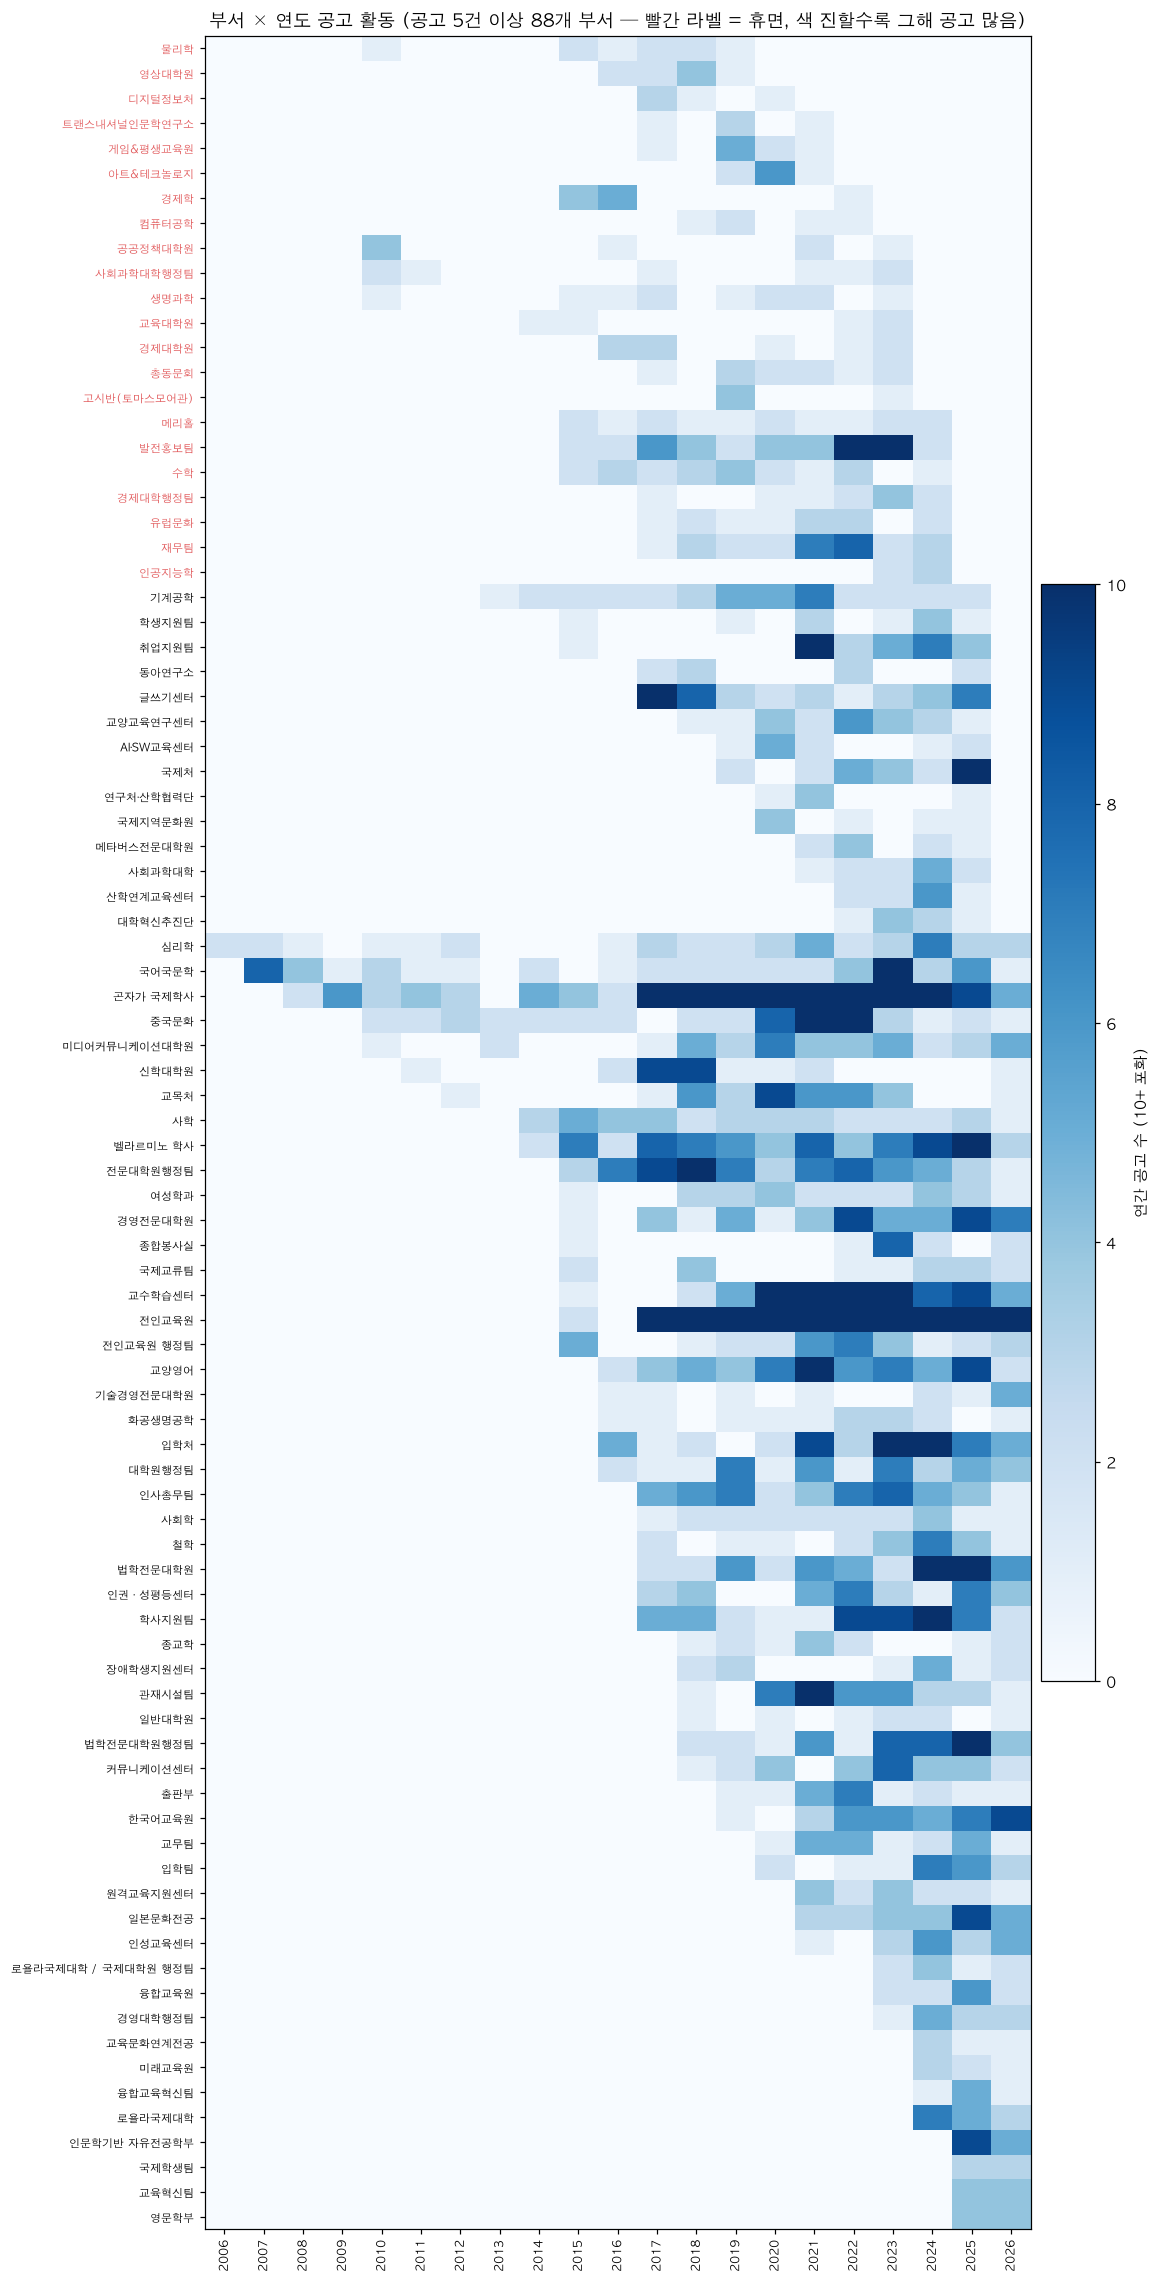

In [15]:
# 부서 × 연도 활동 히트맵 — 누가 언제까지 공고를 냈는지 한눈에
# (공고 5건 이상 부서, 마지막 공고가 오래된 순으로 정렬 → 위쪽 행일수록 일찍 끊긴 부서)
act = df[df['org'].notna() & df['year'].notna()]
act = act[act['org'].isin(last[last['공고수'] >= 5].index)]
hm = act.pivot_table(index='org', columns='year', values='post_id', aggfunc='count').fillna(0)
hm.columns = hm.columns.astype(int)
hm = hm.reindex(columns=range(int(hm.columns.min()), int(hm.columns.max()) + 1), fill_value=0)
# 정렬: 1차 마지막 공고 연도(오래된 순) → 2차 첫 공고 연도(일찍 시작한 부서 먼저)
_meta = last.loc[hm.index]
hm = hm.loc[_meta.assign(_end=_meta['마지막공고'].dt.year, _start=_meta['첫공고'].dt.year)
            .sort_values(['_end', '_start', '마지막공고']).index]

fig, ax = plt.subplots(figsize=(11, 0.22 * len(hm) + 1.5))
im = ax.imshow(hm.clip(upper=10).values, cmap='Blues', aspect='auto',
               vmin=0, vmax=10, interpolation='nearest')
ax.set_xticks(range(len(hm.columns)), hm.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(hm)), hm.index, fontsize=7.5)
dormant_set = set(last[last['휴면_5건']].index)
for lbl in ax.get_yticklabels():
    if lbl.get_text() in dormant_set:
        lbl.set_color(BAD)
ax.set_title(f'부서 × 연도 공고 활동 (공고 5건 이상 {len(hm)}개 부서 — '
             f'빨간 라벨 = 휴면, 색 진할수록 그해 공고 많음)')
cbar = plt.colorbar(im, shrink=0.5, pad=0.01)
cbar.set_label('연간 공고 수 (10+ 포화)')
plt.tight_layout(); plt.show()

In [16]:
# 청년광장 이용이 끊긴 부서 — 공식 채널에서 이탈한 곳
CUT_M = 24
scc_users = last[last['마지막_청년광장'].notna()].copy()
scc_users['청광경과개월'] = ((asof - scc_users['마지막_청년광장']).dt.days / 30.4).round(1)
scc_left = scc_users[(scc_users['청광경과개월'] >= CUT_M) & (scc_users['경과개월'] < CUT_M)]
print(f"청년광장 게시 이력이 있는 부서 {len(scc_users)}개 중,")
print(f"청년광장은 {CUT_M}개월+ 무게시인데 다른 채널에선 최근에도 활동: {len(scc_left)}개")
scc_left[['공고수', '마지막_청년광장', '마지막공고']].sort_values('마지막_청년광장')

청년광장 게시 이력이 있는 부서 111개 중,
청년광장은 24개월+ 무게시인데 다른 채널에선 최근에도 활동: 15개


,공고수,마지막_청년광장,마지막공고
org,,,
벨라르미노 학사,77,2021-05-12,2026-07-15
AI·SW교육센터,11,2021-06-02,2025-02-19
신학대학원,26,2021-08-23,2026-03-09
연구처·산학협력단,6,2021-12-24,2025-02-28
재무팀,28,2022-03-18,2024-12-05
출판부,19,2022-08-11,2026-02-24
중국문화,59,2022-08-18,2026-01-07
수학,21,2022-12-23,2024-08-17
커뮤니케이션센터,29,2023-02-05,2026-07-06


## 8. 채널별 정보 공개율

지원자 의사결정에 필요한 **핵심 8개 항목**(임금·근무시간·근무기간·모집인원·마감일·자격·지원방법·문의처)의
기재율. 공고 1건의 **정보 충실도** = 기재된 항목 비율(0~100점).
(채용 경로의 공개성과는 다른 지표다 — 공개성은 7절 참조.)

> 서담은 초기 크롤링의 셀렉터 버그로 본문이 누락됐었으나 2026-07-25 재수집·재정제 완료.
> 재수집 실패 60건(삭제 게시물)은 미기재로 집계된다.

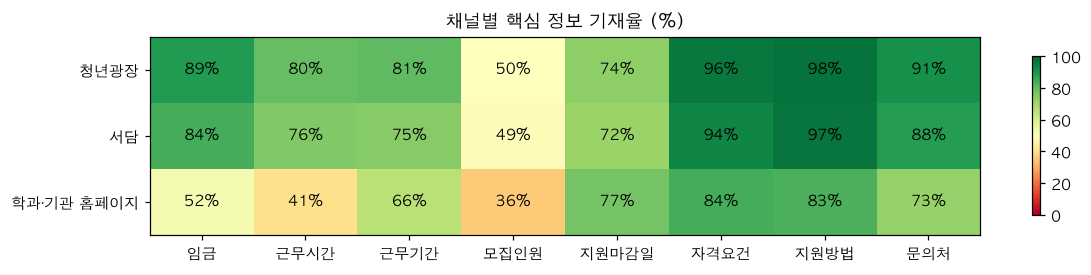

,임금,근무시간,근무기간,모집인원,지원마감일,자격요건,지원방법,문의처,평균(정보충실도)
channel,,,,,,,,,
청년광장,88.8,80.0,80.6,50.1,73.6,96.4,97.5,91.4,82.3
서담,84.2,75.6,74.9,49.0,71.8,93.7,97.2,88.4,79.4
학과·기관 홈페이지,52.4,40.5,66.3,35.8,77.4,84.3,83.2,72.6,64.1


In [17]:
IND_COLS = [f'공개_{k}' for k in FIELD_LABELS]
ch_fields = df.groupby('channel')[IND_COLS].mean() * 100
ch_fields.columns = list(FIELD_LABELS)
ch_fields = ch_fields.loc[CH_ORDER]
ch_fields['평균(정보충실도)'] = df.groupby('channel')['정보충실도'].mean().loc[ch_fields.index]

fig, ax = plt.subplots(figsize=(11, 2.6))
im = ax.imshow(ch_fields[list(FIELD_LABELS)].values, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(len(FIELD_LABELS)), list(FIELD_LABELS))
ax.set_yticks(range(len(ch_fields)), ch_fields.index)
for i in range(len(ch_fields)):
    for j in range(len(FIELD_LABELS)):
        ax.text(j, i, f'{ch_fields[list(FIELD_LABELS)].values[i, j]:.0f}%',
                ha='center', va='center', color='black', fontsize=10)
ax.set_title('채널별 핵심 정보 기재율 (%)')
plt.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.show()
ch_fields.round(1)

## 9. 부서별 정보 충실도 랭킹

표본이 적으면 점수가 불안정하므로 **공고 10건 이상** 부서만 랭킹에 포함한다.

랭킹 대상: 공고 10건 이상 67개 부서, 공고 단위 평균 77점


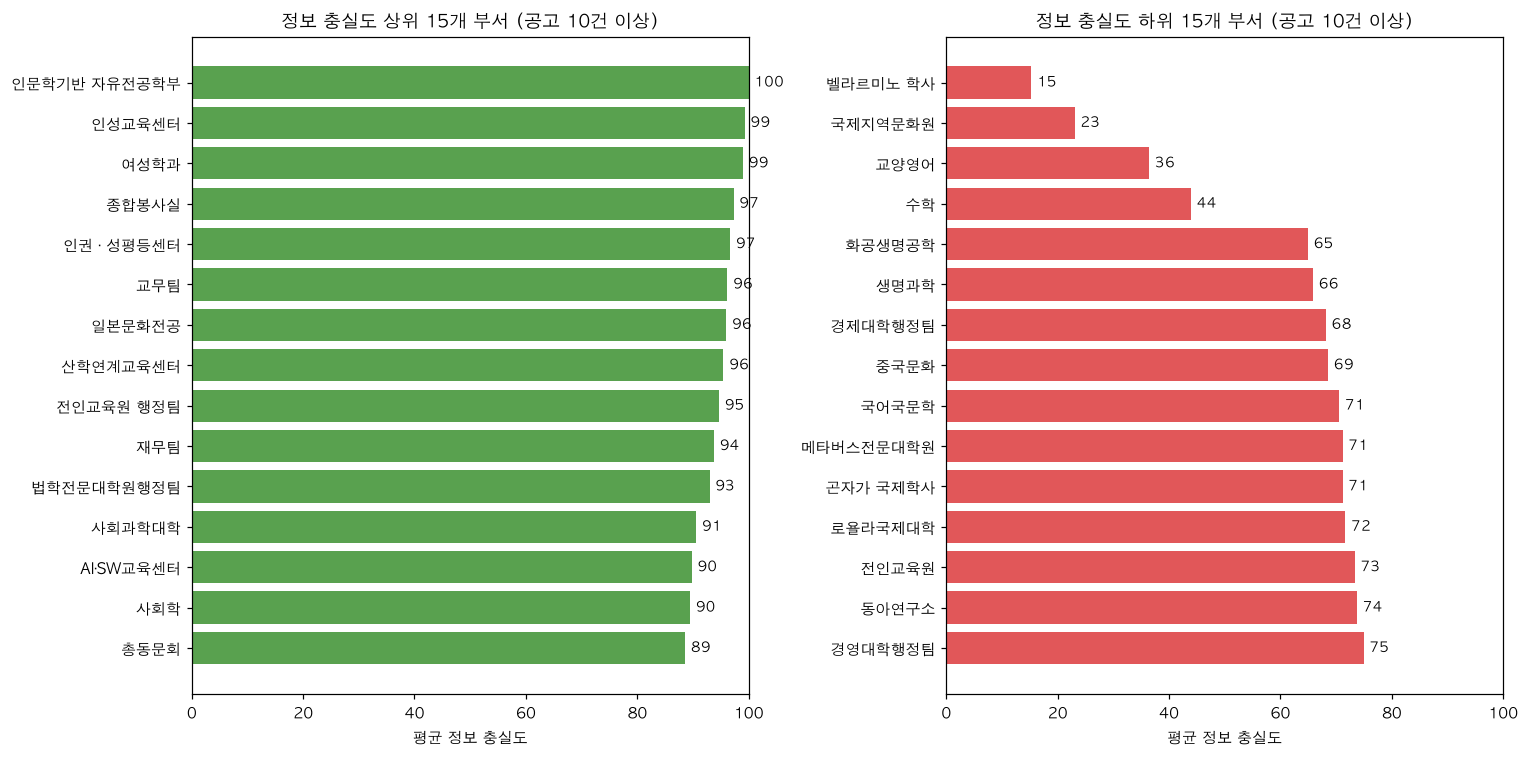

In [18]:
MIN_N = 10
dept_tr = (df[df['org'].notna()].groupby('org')
           .agg(공고수=('post_id', 'size'), 정보충실도=('정보충실도', 'mean')).round(1)
           .join(mat['주채널']))
ranked = dept_tr[dept_tr['공고수'] >= MIN_N].sort_values('정보충실도', ascending=False)
print(f"랭킹 대상: 공고 {MIN_N}건 이상 {len(ranked)}개 부서, "
      f"공고 단위 평균 {df['정보충실도'].mean():.0f}점")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
top15, bot15 = ranked.head(15).iloc[::-1], ranked.tail(15)
axes[0].barh(top15.index, top15['정보충실도'], color=GOOD)
axes[0].set_title(f'정보 충실도 상위 15개 부서 (공고 {MIN_N}건 이상)')
axes[1].barh(bot15.index, bot15['정보충실도'], color=BAD)
axes[1].set_title(f'정보 충실도 하위 15개 부서 (공고 {MIN_N}건 이상)')
for ax, data in zip(axes, (top15, bot15)):
    ax.set_xlim(0, 100); ax.set_xlabel('평균 정보 충실도')
    for y, v in enumerate(data['정보충실도']):
        ax.text(v + 1, y, f'{v:.0f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

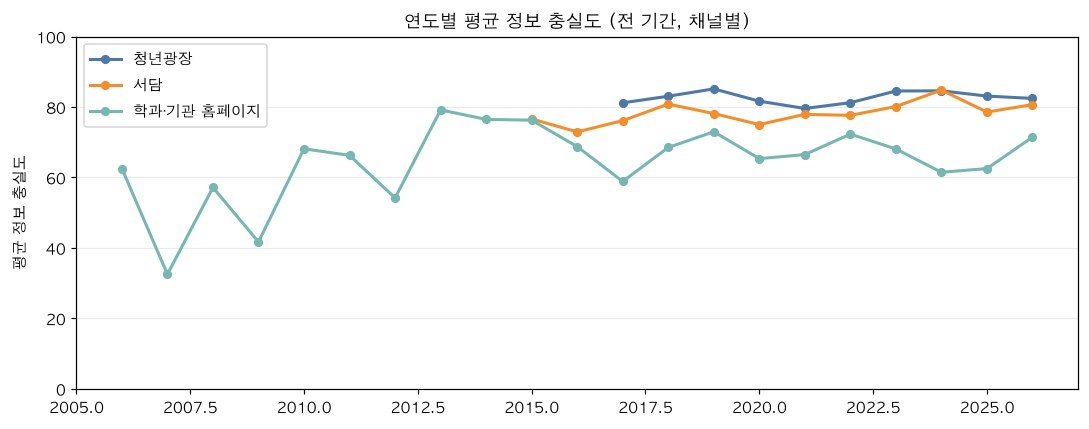

In [19]:
# 정보 충실도 시계열 — 개선되고 있는가
tr_yr = (df[df['year'].notna()]
         .groupby(['year', 'channel'])['정보충실도'].mean().unstack())
fig, ax = plt.subplots(figsize=(10, 4))
for c in CH_ORDER:
    if c in tr_yr.columns:
        ax.plot(tr_yr.index, tr_yr[c], marker='o', markersize=5,
                linewidth=2, color=CH_COLORS[c], label=c)
ax.set_title('연도별 평균 정보 충실도 (전 기간, 채널별)')
ax.set_ylabel('평균 정보 충실도'); ax.set_ylim(0, 100)
ax.legend(); ax.grid(axis='y', alpha=0.25)
plt.tight_layout(); plt.show()

## 10. 모집 리드타임 — 공고 게시일부터 마감일까지

리드타임이 짧을수록 학생이 공고를 발견하고 지원할 시간이 부족하다.

리드타임 계산 가능: 1,850건 / 2,595건 (71%)
전체: 21%가 게시 후 3일 이내, 63%가 7일 이내 마감


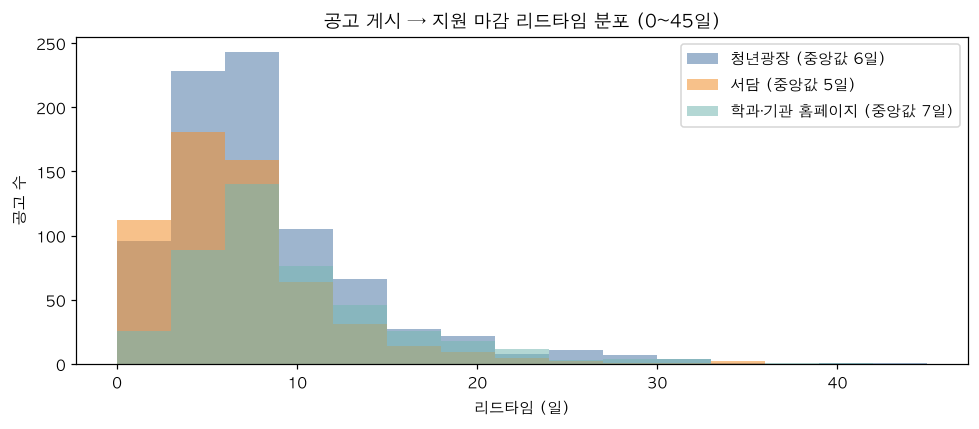

In [20]:
lt = lead_times(df)
print(f"리드타임 계산 가능: {len(lt):,}건 / {len(df):,}건 ({len(lt) / len(df):.0%})")

fig, ax = plt.subplots(figsize=(9, 4))
for c in CH_ORDER:
    s = lt.loc[lt['channel'] == c, '리드타임']
    if len(s):
        ax.hist(s, bins=range(0, 46, 3), alpha=0.55,
                label=f'{c} (중앙값 {s.median():.0f}일)', color=CH_COLORS[c])
ax.set_title('공고 게시 → 지원 마감 리드타임 분포 (0~45일)')
ax.set_xlabel('리드타임 (일)'); ax.set_ylabel('공고 수')
ax.legend()
plt.tight_layout(); plt.show()

print(f"전체: {(lt['리드타임'] <= 3).mean():.0%}가 게시 후 3일 이내, "
      f"{(lt['리드타임'] <= 7).mean():.0%}가 7일 이내 마감")

## 11. 크로스 포스팅 — 같은 모집을 여러 채널에 알렸는가

두 가지 정의로 상·하한을 추정한다.

- **제목 완전일치** (하한): 부서+정규화 제목이 같으면 같은 공고. 채널마다 제목을
  조금이라도 바꾸면 다른 공고로 세므로 보수적.
- **직무·기간 기반** (상한): 같은 부서·같은 직무(role)의 공고가 7일 이내 간격이면
  하나의 '모집 건'. 제목이 달라도 잡히지만, 같은 직무를 우연히 같은 주에
  두 번 모집한 경우도 하나로 묶일 수 있다.

이어서 **한 채널만 보는 학생이 전체 모집 건 중 몇 %를 놓치는지**(채널 커버리지)를 계산한다.

In [21]:
s1 = cross_posting_stats(df)
s2 = cross_posting_role_window(df, window_days=7)
print(f"[제목 완전일치] 고유 공고 {s1['unique_postings']:,}건 중 "
      f"복수 채널 게시 {s1['cross_channel']}건 ({s1['cross_ratio']:.1%})")
print(f"[직무·7일 기간] 모집 건 {s2['unique_recruitments']:,}건 중 "
      f"복수 채널 게시 {s2['cross_channel']}건 ({s2['cross_ratio']:.1%})"
      f" — 직무 추출된 공고 기준 (커버리지 {s2['coverage']:.0%})")
print(f"→ 어떤 정의로도 모집 건의 {max(s1['cross_ratio'], s2['cross_ratio']):.0%} 이하만 복수 채널에 게시")

# 한 채널만 보는 학생이 놓치는 모집 건 비율 (6절의 고유 모집 건 기준)
print()
print(f"채널별 커버리지 — 그 채널만 보는 학생이 놓치는 모집 건 비율 (모집 건 {len(df_u):,}건 기준):")
coverage = {}
for c in CH_ORDER:
    seen = df_u['channels'].map(lambda ch: c in ch).mean()
    coverage[c] = seen
    print(f"  {c:12s}만 보면: 전체 모집 건의 {1 - seen:.0%} 놓침 (커버 {seen:.0%})")
pub = df_u['channels'].map(lambda ch: '청년광장' in ch or '서담' in ch).mean()
print(f"  {'청년광장+서담':12s} 둘 다 봐도: {1 - pub:.0%} 놓침 (학과 홈페이지에만 게시된 모집 건)")

[제목 완전일치] 고유 공고 1,762건 중 복수 채널 게시 174건 (9.9%)
[직무·7일 기간] 모집 건 1,991건 중 복수 채널 게시 317건 (15.9%) — 직무 추출된 공고 기준 (커버리지 98%)
→ 어떤 정의로도 모집 건의 16% 이하만 복수 채널에 게시

채널별 커버리지 — 그 채널만 보는 학생이 놓치는 모집 건 비율 (모집 건 2,087건 기준):
  청년광장        만 보면: 전체 모집 건의 49% 놓침 (커버 51%)
  서담          만 보면: 전체 모집 건의 66% 놓침 (커버 34%)
  학과·기관 홈페이지  만 보면: 전체 모집 건의 69% 놓침 (커버 31%)
  청년광장+서담      둘 다 봐도: 26% 놓침 (학과 홈페이지에만 게시된 모집 건)


## 12. 요약 — 전략에 바로 쓸 핵심 수치

In [22]:
lines = []
lines.append('━━━ 데이터 규모 ━━━')
n_dept_src = df.loc[df.source.str.startswith('dept_'), 'source'].nunique()
lines.append(f'· 교내 근로 공고 {len(df):,}건, 공고 주체 {len(mat)}개 부서·기관')
lines.append(f'· 채널: 청년광장 {len(df[df.channel == "청년광장"]):,}건 / 서담 {len(df[df.channel == "서담"]):,}건 / '
             f'학과·기관 홈페이지 {n_dept_src}곳 {len(df[df.channel == "학과·기관 홈페이지"]):,}건')

lines.append('')
lines.append('━━━ 채널 분산(파편화) ━━━')
lines.append(f'· 부서의 {(mat["사용채널수"] == 1).mean():.0%}가 단일 채널만 사용')
lines.append(f'· 서담(로그인 필요·비공식)에만 공고를 낸 부서 {len(ssodam_only)}개 ({len(ssodam_only) / len(mat):.0%})')
lines.append(f'· 복수 채널 게시는 모집 건의 {s1["cross_ratio"]:.0%}(제목 기준)~{s2["cross_ratio"]:.0%}(직무 기준)에 불과')
lines.append('· 한 채널만 보면 놓치는 모집 건: ' + ', '.join(
    f'{c} {1 - coverage[c]:.0%}' for c in CH_ORDER))

lines.append('')
lines.append('━━━ 채용 공개성 (조직도 대비 — 비공개 채용 신호) ━━━')
n_out_w = {c: len(tier_cmp) - tier_cmp[c].str.startswith('A').sum() for c in tier_cmp.columns}
lines.append('· 공개성 지수(학과 공개율): ' + ' → '.join(
    f'{c} {1 - n_out_w[c] / len(tier_cmp):.0%}' for c in tier_cmp.columns))
lines.append(f'· 공개 채널 밖 학과: 전체 {n_out_w["전체"]}개 → 2022년 이후 {n_out_w["2022이후"]}개 → '
             f'2025년 이후 {n_out_w["2025이후"]}개 (/{len(tier_cmp)}개, 판정 기간을 좁힐수록 악화)')
lines.append(f'· 학과 외에도 {len(worse_o)}개 부서가 공개 채널에 올리다가 2025년 이후 중단')
lines.append(f'· 휴면 부서(5건+, {DORMANT_M}개월+ 무게시) {len(dormant)}개, 청년광장 이탈 {len(scc_left)}개')

lines.append('')
lines.append('━━━ 시기별 ━━━')
lines.append(f'· 공고는 {", ".join(f"{m}월" for m in top_months.index)}에 집중 '
             f'(상위 3개월 {top_months.sum() / monthly.sum().sum():.0%})')
lines.append('· 채널 비중 이동(2015–19→2024–26): ' + ', '.join(
    f'{c} {yr_pct.loc[2015:2019, c].mean():.0%}→{yr_pct.loc[2024:2026, c].mean():.0%}' for c in CH_ORDER))

lines.append('')
lines.append('━━━ 정보 충실도·접근성 ━━━')
lines.append(f'· 평균 정보 충실도 {df["정보충실도"].mean():.0f}점/100 — 채널 격차: '
             + ' vs '.join(f'{c} {ch_fields.loc[c, "평균(정보충실도)"]:.0f}점' for c in CH_ORDER))
lines.append(f'· 부서 격차(10건+): 최고 {ranked["정보충실도"].max():.0f}점({ranked.index[0]}) vs '
             f'최저 {ranked["정보충실도"].min():.0f}점({ranked.index[-1]})')
lines.append(f'· 게시·마감일 모두 기재 {len(lt) / len(df):.0%}, 그중 {(lt["리드타임"] <= 7).mean():.0%}는 7일 내 마감')

print('\n'.join(lines))

━━━ 데이터 규모 ━━━
· 교내 근로 공고 2,595건, 공고 주체 160개 부서·기관
· 채널: 청년광장 1,127건 / 서담 812건 / 학과·기관 홈페이지 33곳 656건

━━━ 채널 분산(파편화) ━━━
· 부서의 42%가 단일 채널만 사용
· 서담(로그인 필요·비공식)에만 공고를 낸 부서 26개 (16%)
· 복수 채널 게시는 모집 건의 10%(제목 기준)~16%(직무 기준)에 불과
· 한 채널만 보면 놓치는 모집 건: 청년광장 49%, 서담 66%, 학과·기관 홈페이지 69%

━━━ 채용 공개성 (조직도 대비 — 비공개 채용 신호) ━━━
· 공개성 지수(학과 공개율): 전체 69% → 2022이후 56% → 2025이후 31%
· 공개 채널 밖 학과: 전체 10개 → 2022년 이후 14개 → 2025년 이후 22개 (/32개, 판정 기간을 좁힐수록 악화)
· 학과 외에도 34개 부서가 공개 채널에 올리다가 2025년 이후 중단
· 휴면 부서(5건+, 18개월+ 무게시) 22개, 청년광장 이탈 15개

━━━ 시기별 ━━━
· 공고는 8월, 2월, 12월에 집중 (상위 3개월 48%)
· 채널 비중 이동(2015–19→2024–26): 청년광장 33%→45%, 서담 40%→37%, 학과·기관 홈페이지 27%→18%

━━━ 정보 충실도·접근성 ━━━
· 평균 정보 충실도 77점/100 — 채널 격차: 청년광장 82점 vs 서담 79점 vs 학과·기관 홈페이지 64점
· 부서 격차(10건+): 최고 100점(인문학기반 자유전공학부) vs 최저 15점(벨라르미노 학사)
· 게시·마감일 모두 기재 71%, 그중 63%는 7일 내 마감


### 산출물과 재현

- 분석 CSV(`data/analysis/*.csv`)는 **`python -m analysis`** 로 재생성한다 (이 노트북은 저장하지 않음).
- 조직명 매핑·직무 추출을 갱신하려면 `python -m crawler enrich`.

### 채용 공개성을 더 직접 수치화하려면 (제안)

현재 공개성 지수는 "공고를 공개 채널에 냈는가"만 본다. 비공개 채용의 **규모** 자체를
추정하려면 공고 데이터 밖의 분모가 필요하다.

1. **공시 데이터 대조 (공개 공고 커버리지)** — 대학알리미(대학정보공시)의 연도별
   교내근로장학금 수혜 인원을 분모로: `공개 채널에 공고된 모집인원 합계 ÷ 실제 근로 학생 수`.
   이 비율이 낮을수록 공고 없이 채워진 자리가 많다는 뜻. (모집인원 기재율 46%이므로
   공고 측 합계는 하한 보정 필요 — 미기재 공고는 중앙값 인원으로 대체하는 식.)
2. **재학생 설문** — 교내 근로 경험자에게 "그 자리를 어떻게 알게 됐나"
   (공개 공고 / 교수·조교 권유 / 지인 소개)를 물으면 비공개 채용 비율을 직접 측정할 수
   있다. STREAM 사전 수요조사에 문항 2~3개로 얹을 수 있는 규모.

### 해석 시 유의사항

- **판정 확정성**: 청년광장·서담은 전수 수집이므로 "공개 채널에 없다"(B·C)는 확정적.
  홈페이지는 게시판이 확인된 46개 사이트 기준 — 화학과는 자체 게시판이 없고,
  경제·경영은 신형 CMS(new-cms SPA)라 미수집 (둘 다 청년광장 이력이 있어 등급 판정 영향 없음).
- **짧은 판정 기간의 보수성**: '2025년 이후'는 약 3개 학기 분량이라 모집 빈도가 낮은
  부서는 "아직 안 올린 것"일 수 있다. 세 기간을 나란히 보는 이유.
- **정제 품질**: 필드 기재율·직무·조직명 매핑은 Gemini 정제 결과 기준. 절대값보다
  채널·부서 간 **상대 비교**로 해석. 개편 학과(유럽문화 등)는 옛 명칭 이력으로 연결했다.